In [1]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline
import torch.nn.functional as F

In [2]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# building the vocabulary of the characters and mapping them to /from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next token
X, Y = [], []
for w in words:
    
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(f"{''.join(itos[i] for i in context)} ----> {itos[ix]}")
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [57]:
g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn((27), generator=g)
parameters = [C,W1,b1,W2,b2]

In [58]:
sum(p.nelement() for p in parameters) # total number of parameters

3481

In [59]:
for p in parameters:
    p.requires_grad = True

In [60]:
lre = torch.linspace(-3,1, 1000)
lrs = 10**lre

In [61]:
lri = []
lossi = []

for i in range(1000):

    # mini batches ix
    ix = torch.randint(0,X.shape[0],(32,))

    # forward pass
    emb = C[X[ix]] # still 32,3,2
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())
    

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    lri.append(lr)
    lossi.append(loss.item())

#print(loss.item())

19.282133102416992
19.898365020751953
19.756193161010742
16.835956573486328
20.02911949157715
17.80902099609375
19.32522964477539
16.946828842163086
21.296310424804688
19.433443069458008
18.7596435546875
19.9488468170166
21.398313522338867
20.757970809936523
17.553319931030273
20.22783660888672
18.00900650024414
20.060779571533203
19.694324493408203
18.61467933654785
20.72328758239746
22.74431610107422
18.434127807617188
18.28714942932129
21.575927734375
21.241191864013672
20.441831588745117
19.8405818939209
16.25701904296875
19.993993759155273
17.114479064941406
19.118391036987305
16.372848510742188
15.909311294555664
19.24165153503418
16.941652297973633
16.89832878112793
17.53650665283203
17.153846740722656
18.067251205444336
17.80673599243164
15.931160926818848
17.68026351928711
16.411911010742188
17.965106964111328
14.855762481689453
16.149822235107422
19.872404098510742
19.021211624145508
17.985445022583008
15.291860580444336
18.971473693847656
17.51982307434082
19.360610961914062

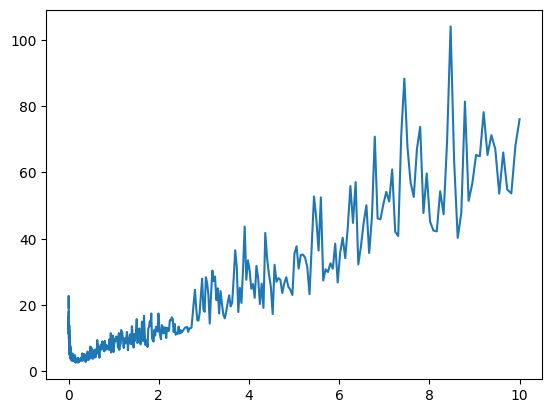

In [62]:
plt.plot(lri,lossi)

In [63]:
emb = C[X[ix]] # still 32,3,2
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits, Y[ix])
loss

tensor(35.1311, grad_fn=<NllLossBackward0>)